# NeuroShield AI — Stroke Model Training & Evaluation

This notebook is the model-training workflow for the **binary stroke-classification problem**.

### What is improved
- Uses a **stratified validation split** from the training data.
- Handles the severe class imbalance using **class weighting / positive-class weighting**.
- Trains Logistic Regression, Random Forest, HistGradientBoosting, XGBoost and LightGBM.
- Reports **Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC (Average Precision)**.
- Uses **probabilities and validation-based threshold tuning** instead of relying only on the default 0.50 threshold.
- Keeps the **test set untouched** until final evaluation.
- Produces confusion matrices and precision-recall curves.
- Saves the selected model and its threshold for later inference.

> **Important:** This is a machine-learning research/prototyping workflow, not a clinical diagnostic system.


## 1. Import libraries

In [ ]:
import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
)
from sklearn.base import clone

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "Ever_told_you_had_a_stroke"

print("Libraries loaded.")


Libraries loaded.


## 2. Load the already-transformed training and test data

In [ ]:
# These paths match the project structure used in the original notebook.
TRAIN_PATH = Path("../dataset/processed/transformed_train.csv")
TEST_PATH = Path("../dataset/processed/transformed_test.csv")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)


Training shape: (345242, 48)
Test shape: (86311, 48)


## 3. Clean feature names consistently

The transformed CSV can contain prefixes such as `binary__`, `multi__`, `ordinal__`, and `remainder__`, as well as characters that some gradient-boosting libraries reject. The same cleaning is applied to both datasets so feature names remain aligned.


In [3]:
def clean_column_name(col):
    col = str(col)
    col = re.sub(r'^(binary|multi|ordinal|remainder)__', '', col)
    col = re.sub(r'[^A-Za-z0-9_]+', '_', col)
    col = re.sub(r'_+', '_', col)
    return col.strip('_').lower()

train_df.columns = [clean_column_name(c) for c in train_df.columns]
test_df.columns = [clean_column_name(c) for c in test_df.columns]

target_candidates = [c for c in train_df.columns if c.lower() == TARGET.lower()]
if not target_candidates:
    raise ValueError(
        f"Target column not found. Available columns include: {train_df.columns[-10:].tolist()}"
    )

TARGET = target_candidates[0]

if TARGET not in test_df.columns:
    raise ValueError("Target column is missing from transformed_test.csv.")

# Make sure the feature sets are identical and in the same order.
feature_columns = [c for c in train_df.columns if c != TARGET]
missing_in_test = [c for c in feature_columns if c not in test_df.columns]
extra_in_test = [c for c in test_df.columns if c not in feature_columns + [TARGET]]

if missing_in_test or extra_in_test:
    raise ValueError(
        f"Train/test feature mismatch. Missing in test: {missing_in_test}; "
        f"Extra in test: {extra_in_test}"
    )

X = train_df[feature_columns].copy()
y = pd.to_numeric(train_df[TARGET], errors="coerce").astype(int)

X_test = test_df[feature_columns].copy()
y_test = pd.to_numeric(test_df[TARGET], errors="coerce").astype(int)

print("Target:", TARGET)
print("Number of features:", X.shape[1])
print("X:", X.shape, "y:", y.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


Target: ever_told_you_had_a_stroke
Number of features: 47
X: (345242, 47) y: (345242,)
X_test: (86311, 47) y_test: (86311,)


## 4. Check target distribution and basic integrity

In [4]:
print("Training target distribution:")
print(y.value_counts().sort_index())

print("\nTraining target proportions:")
print(y.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

print("\nMissing values:")
print("X:", int(X.isna().sum().sum()))
print("y:", int(y.isna().sum()))
print("X_test:", int(X_test.isna().sum().sum()))
print("y_test:", int(y_test.isna().sum()))

if set(y.unique()) != {0, 1}:
    raise ValueError(f"Expected binary target encoded as 0/1, found: {sorted(y.unique())}")

if set(y_test.unique()) != {0, 1}:
    raise ValueError(f"Expected binary test target encoded as 0/1, found: {sorted(y_test.unique())}")


Training target distribution:
ever_told_you_had_a_stroke
0    330571
1     14671
Name: count, dtype: int64

Training target proportions:
ever_told_you_had_a_stroke
0    0.957505
1    0.042495
Name: proportion, dtype: float64

Test target distribution:
ever_told_you_had_a_stroke
0    82643
1     3668
Name: count, dtype: int64

Missing values:
X: 0
y: 0
X_test: 0
y_test: 0


## 5. Create a validation set

The original training data is split into **80% model-training data and 20% validation data**, using stratification so the minority stroke class remains represented.

The original held-out test set is **not used for threshold selection or model selection**.


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train distribution:")
print(y_train.value_counts().sort_index())
print("y_val distribution:")
print(y_val.value_counts().sort_index())

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()
scale_pos_weight = negative_count / positive_count

print(f"\nScale positive weight: {scale_pos_weight:.3f}")


X_train: (276193, 47)
X_val: (69049, 47)
y_train distribution:
ever_told_you_had_a_stroke
0    264456
1     11737
Name: count, dtype: int64
y_val distribution:
ever_told_you_had_a_stroke
0    66115
1     2934
Name: count, dtype: int64

Scale positive weight: 22.532


## 6. Define class-imbalance-aware models

The minority stroke class is much smaller than the non-stroke class, so accuracy by itself can be misleading.

- Logistic Regression / Random Forest use `class_weight="balanced"`.
- XGBoost / LightGBM use a calculated `scale_pos_weight`.
- HistGradientBoosting is retained as a comparison model.


In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
}

# XGBoost and LightGBM are optional dependencies in case the environment does not have them.
try:
    from xgboost import XGBClassifier

    models["XGBoost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    print("XGBoost available.")
except ImportError:
    print("XGBoost not installed — skipping XGBoost.")

try:
    from lightgbm import LGBMClassifier

    models["LightGBM"] = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
    print("LightGBM available.")
except ImportError:
    print("LightGBM not installed — skipping LightGBM.")

print("\nModels:", list(models))


XGBoost available.
LightGBM available.

Models: ['Logistic Regression', 'Random Forest', 'Hist Gradient Boosting', 'XGBoost', 'LightGBM']


## 7. Train models and generate validation probabilities

In [7]:
trained_models = {}
validation_probabilities = {}

for name, model in models.items():
    print(f"Training {name}...")
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)
    trained_models[name] = fitted_model
    validation_probabilities[name] = fitted_model.predict_proba(X_val)[:, 1]

print("\nTraining complete.")


Training Logistic Regression...
Training Random Forest...
Training Hist Gradient Boosting...
Training XGBoost...
Training LightGBM...

Training complete.


## 8. Tune the classification threshold on validation data

`predict()` normally uses a 0.50 threshold. With an imbalanced medical classification problem, that threshold may produce very few positive predictions.

Here the threshold is selected **only on the validation set** by maximizing the validation **F1-score**. The test set remains untouched.

The chosen threshold is therefore a model-selection result, not a clinical cutoff.


In [8]:
def find_best_f1_threshold(y_true, probabilities):
    thresholds = np.linspace(0.01, 0.99, 197)
    scores = []

    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        scores.append(f1_score(y_true, predictions, zero_division=0))

    best_index = int(np.argmax(scores))
    return float(thresholds[best_index]), float(scores[best_index])

thresholds = {}
for name, probabilities in validation_probabilities.items():
    threshold, best_f1 = find_best_f1_threshold(y_val, probabilities)
    thresholds[name] = threshold
    print(f"{name}: threshold={threshold:.3f}, validation F1={best_f1:.4f}")


Logistic Regression: threshold=0.780, validation F1=0.2617
Random Forest: threshold=0.250, validation F1=0.2416
Hist Gradient Boosting: threshold=0.125, validation F1=0.2652
XGBoost: threshold=0.740, validation F1=0.2575
LightGBM: threshold=0.765, validation F1=0.2603


## 9. Compare models on the validation set

In [9]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)

    return {
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probabilities),
        "PR-AUC": average_precision_score(y_true, probabilities),
        "Threshold": threshold,
    }

validation_results = []
for name, probabilities in validation_probabilities.items():
    row = {"Model": name}
    row.update(evaluate_probabilities(y_val, probabilities, thresholds[name]))
    validation_results.append(row)

validation_results_df = pd.DataFrame(validation_results).sort_values(
    ["PR-AUC", "F1"], ascending=False
).reset_index(drop=True)

display(validation_results_df.round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Threshold
0,Hist Gradient Boosting,0.9063,0.1989,0.3978,0.2652,0.8290,0.1883,0.125
1,LightGBM,0.9159,0.2078,0.3483,0.2603,0.8251,0.1856,0.765
2,Logistic Regression,0.9122,0.2036,0.3661,0.2617,0.8245,0.1823,0.780
3,XGBoost,0.9071,0.1950,0.3790,0.2575,0.8216,0.1822,0.740
4,Random Forest,0.8864,0.1686,0.4260,0.2416,0.8161,0.1624,0.250


## 10. Select the model using validation PR-AUC

Because the positive stroke class is rare, **PR-AUC is included as a primary model-selection metric**, alongside F1, recall and precision.

This avoids selecting a model merely because it can obtain high accuracy by predicting mostly the majority class.


In [10]:
selected_model_name = validation_results_df.iloc[0]["Model"]
selected_threshold = float(validation_results_df.iloc[0]["Threshold"])
selected_model = trained_models[selected_model_name]

print("Selected model based on highest validation PR-AUC:")
print(selected_model_name)
print(f"Validation threshold: {selected_threshold:.3f}")


Selected model based on highest validation PR-AUC:
Hist Gradient Boosting
Validation threshold: 0.125


## 11. Final evaluation on the untouched test set

Now — and only now — the selected model is evaluated on the held-out test set.

Two views are reported:
1. **Default threshold = 0.50**
2. **Validation-selected threshold**

The second is the threshold that should be used if this model is later used in the project application, subject to further validation.


In [11]:
test_probabilities = selected_model.predict_proba(X_test)[:, 1]

test_default = evaluate_probabilities(y_test, test_probabilities, 0.50)
test_tuned = evaluate_probabilities(y_test, test_probabilities, selected_threshold)

final_comparison = pd.DataFrame([
    {"Evaluation": "Default threshold (0.50)", **test_default},
    {"Evaluation": "Validation-tuned threshold", **test_tuned},
])

display(final_comparison.round(4))

print("\nClassification report using validation-tuned threshold:")
test_predictions_tuned = (test_probabilities >= selected_threshold).astype(int)
print(classification_report(y_test, test_predictions_tuned, digits=4, zero_division=0))


,Evaluation,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Threshold
0,Default threshold (0.50),0.9575,0.0000,0.0000,0.0000,0.8256,0.1876,0.500
1,Validation-tuned threshold,0.9042,0.1924,0.3926,0.2582,0.8256,0.1876,0.125



Classification report using validation-tuned threshold:
              precision    recall  f1-score   support

           0     0.9717    0.9269    0.9488     82643
           1     0.1924    0.3926    0.2582      3668

    accuracy                         0.9042     86311
   macro avg     0.5821    0.6597    0.6035     86311
weighted avg     0.9386    0.9042    0.9194     86311



## 12. Confusion matrix

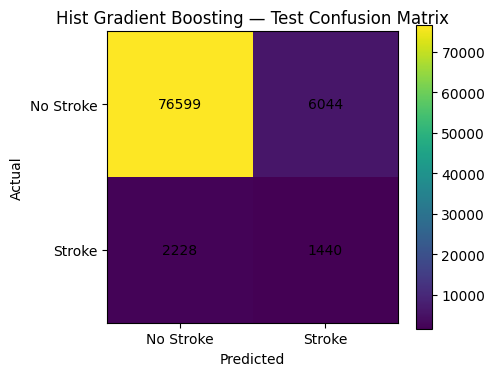

In [12]:
cm = confusion_matrix(y_test, test_predictions_tuned)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)
ax.set_title(f"{selected_model_name} — Test Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_xticks([0, 1], ["No Stroke", "Stroke"])
ax.set_yticks([0, 1], ["No Stroke", "Stroke"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 13. Precision-Recall curves for all models

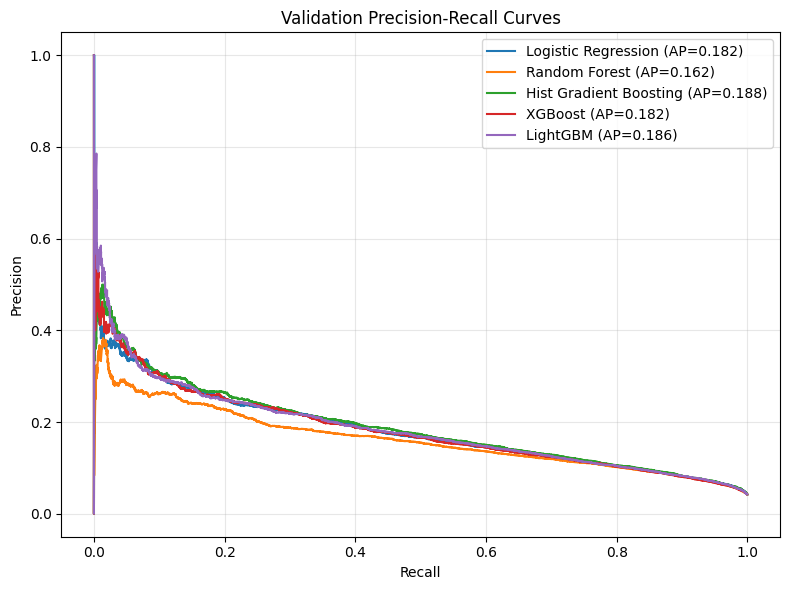

In [13]:
plt.figure(figsize=(8, 6))

for name, probabilities in validation_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_val, probabilities)
    ap = average_precision_score(y_val, probabilities)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Validation Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 14. ROC curves for all models

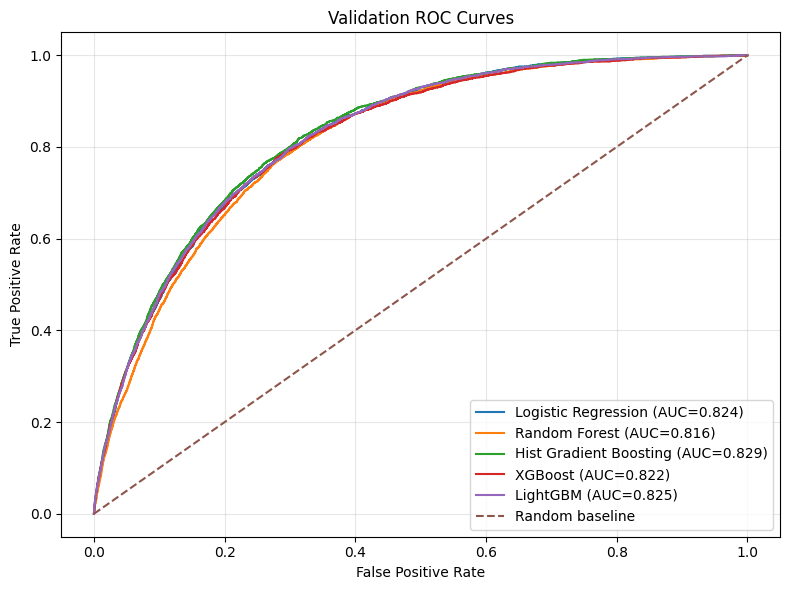

In [14]:
plt.figure(figsize=(8, 6))

for name, probabilities in validation_probabilities.items():
    fpr, tpr, _ = roc_curve(y_val, probabilities)
    auc = roc_auc_score(y_val, probabilities)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Validation ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 15. Retrain the selected model on the complete training set

After model/threshold selection, the selected algorithm is refit on **all available training data**.

The test set is still used only for final evaluation above.

For class-weighted models, the weighting is preserved automatically. For XGBoost/LightGBM, the positive-class weight is recalculated from the complete training set.


In [15]:
final_scale_pos_weight = (y == 0).sum() / (y == 1).sum()

if selected_model_name == "XGBoost":
    final_model = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=final_scale_pos_weight,
        objective="binary:logistic",
        eval_metric="aucpr",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
elif selected_model_name == "LightGBM":
    final_model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=final_scale_pos_weight,
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )
else:
    final_model = clone(models[selected_model_name])

final_model.fit(X, y)

print("Final model trained on:", X.shape[0], "training records")
print("Final model:", selected_model_name)
print("Stored threshold:", selected_threshold)


Final model trained on: 345242 training records
Final model: Hist Gradient Boosting
Stored threshold: 0.125


## 16. Save the final model, feature names and threshold

Saving the threshold is important: if the application later calls `predict_proba()`, it must use the same threshold selected during validation.


In [16]:
import joblib

model_path = MODEL_DIR / "stroke_model_final.pkl"
metadata_path = MODEL_DIR / "stroke_model_metadata.pkl"

joblib.dump(final_model, model_path)

metadata = {
    "model_name": selected_model_name,
    "threshold": selected_threshold,
    "target": TARGET,
    "feature_columns": feature_columns,
    "random_state": RANDOM_STATE,
}

joblib.dump(metadata, metadata_path)

print("Saved:")
print(model_path)
print(metadata_path)


Saved:
..\models\stroke_model_final.pkl
..\models\stroke_model_metadata.pkl


## 17. Final project summary

The important numbers to report are **not accuracy alone**. For this imbalanced binary classification task, report:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix
- Classification threshold

### Interpretation
A lower threshold generally increases recall while reducing precision. The selected threshold in this notebook is an **empirical validation threshold** chosen to maximize F1; it is not a clinical decision threshold.

The model should therefore be presented as a **stroke-risk prediction prototype**, not as a standalone diagnostic tool. External validation, calibration, fairness/subgroup analysis and clinical validation would be required before real-world medical use.
